# Task 1

---

## Web scraping and analysis

This Jupyter notebook includes some code to get you started with web scraping. We will use a package called `BeautifulSoup` to collect the data from the web. Once you've collected your data and saved it into a local `.csv` file you should start with your analysis.

### Scraping data from Skytrax

If you visit [https://www.airlinequality.com] you can see that there is a lot of data there. For this task, we are only interested in reviews related to British Airways and the Airline itself.

If you navigate to this link: [https://www.airlinequality.com/airline-reviews/british-airways] you will see this data. Now, we can use `Python` and `BeautifulSoup` to collect all the links to the reviews and then to collect the text data on each of the individual review links.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

C:\Users\abhis\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
base_url = "https://www.airlinequality.com/airline-reviews/british-airways"
pages = 10
page_size = 100

reviews = []

# for i in range(1, pages + 1):
for i in range(1, pages + 1):

    print(f"Scraping page {i}")

    # Create URL to collect links from paginated data
    url = f"{base_url}/page/{i}/?sortby=post_date%3ADesc&pagesize={page_size}"

    # Collect HTML data from this page
    response = requests.get(url)

    # Parse content
    content = response.content
    parsed_content = BeautifulSoup(content, 'html.parser')
    for para in parsed_content.find_all("div", {"class": "text_content"}):
        reviews.append(para.get_text())
    
    print(f"   ---> {len(reviews)} total reviews")

Scraping page 1
   ---> 100 total reviews
Scraping page 2
   ---> 200 total reviews
Scraping page 3
   ---> 300 total reviews
Scraping page 4
   ---> 400 total reviews
Scraping page 5
   ---> 500 total reviews
Scraping page 6
   ---> 600 total reviews
Scraping page 7
   ---> 700 total reviews
Scraping page 8
   ---> 800 total reviews
Scraping page 9
   ---> 900 total reviews
Scraping page 10
   ---> 1000 total reviews


In [3]:
df = pd.DataFrame()
df["reviews"] = reviews
df.head()

,reviews
0,Not Verified | I am close to retaining Bronze ...
1,✅ Trip Verified | I recently flew Business C...
2,Not Verified | Lounge in Miami was pretty goo...
3,Not Verified | Terminal 5 is a great place to...
4,✅ Trip Verified | Lost my suitcase. Cramped c...


In [4]:
df.to_csv("BA_reviews.csv")

Congratulations! Now you have your dataset for this task! The loops above collected 1000 reviews by iterating through the paginated pages on the website. However, if you want to collect more data, try increasing the number of pages!

 The next thing that you should do is clean this data to remove any unnecessary text from each of the rows. For example, "✅ Trip Verified" can be removed from each row if it exists, as it's not relevant to what we want to investigate.

In [5]:
df

,reviews
0,Not Verified | I am close to retaining Bronze ...
1,✅ Trip Verified | I recently flew Business C...
2,Not Verified | Lounge in Miami was pretty goo...
3,Not Verified | Terminal 5 is a great place to...
4,✅ Trip Verified | Lost my suitcase. Cramped c...
...,...
995,Not Verified | Heathrow to Belfast. Great ser...
996,Not Verified | London to Singapore. I was app...
997,✅ Trip Verified | Toulouse to London. I'm a ab...
998,✅ Trip Verified | London Heathrow to Stockhol...


In [6]:
# Removing the Sentences before '|' in the reviews column

df.reviews= df.reviews.str.split('|',expand=True)[1]

In [7]:
df

,reviews
0,I am close to retaining Bronze status for the...
1,I recently flew Business Class on BA95 from...
2,Lounge in Miami was pretty good (much better...
3,"Terminal 5 is a great place to fly from, par..."
4,Lost my suitcase. Cramped cabin with a seat ...
...,...
995,Heathrow to Belfast. Great service in Belfas...
996,London to Singapore. I was apprehensive abou...
997,"Toulouse to London. I'm a able bodied, fit BA..."
998,London Heathrow to Stockholm. Business class...


S1:- Cleaning the text

In [8]:
import re

# Define a function to clean the text
def clean(text):
# Removes all special characters and numericals leaving the alphabets
    text = re.sub('[^A-Za-z]+', ' ', str(text))
    return text

# Cleaning the text in the review column
df['Cleaned Reviews'] = df['reviews'].apply(clean)
df.head()

,reviews,Cleaned Reviews
0,I am close to retaining Bronze status for the...,I am close to retaining Bronze status for the...
1,I recently flew Business Class on BA95 from...,I recently flew Business Class on BA from Lon...
2,Lounge in Miami was pretty good (much better...,Lounge in Miami was pretty good much better t...
3,"Terminal 5 is a great place to fly from, par...",Terminal is a great place to fly from particu...
4,Lost my suitcase. Cramped cabin with a seat ...,Lost my suitcase Cramped cabin with a seat pi...


In [9]:
'''This tokenizer divides a text into a list of sentences by using an unsupervised algorithm to build a model for abbreviation words, collocations, and words that start sentences.'''

import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from nltk import pos_tag
nltk.download('stopwords')
from nltk.corpus import stopwords
nltk.download('wordnet')
from nltk.corpus import wordnet

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [11]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.tag import pos_tag

# Download all required resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')  
# POS dictionary
pos_dict = {
    'J': wordnet.ADJ,
    'V': wordnet.VERB,
    'N': wordnet.NOUN,
    'R': wordnet.ADV
}

# Cache stopwords (IMPORTANT for performance)
stop_words = set(stopwords.words('english'))

def token_stop_pos(text):
    if not isinstance(text, str):   #  handle NaN / non-text
        return []
    
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)
    
    newlist = []
    for word, tag in tags:
        if word.lower() not in stop_words:
            newlist.append((word, pos_dict.get(tag[0], None)))  # safe get
    
    return newlist

# Apply function
df['POS tagged'] = df['Cleaned Reviews'].apply(token_stop_pos)

# Show result
df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\abhis\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


,reviews,Cleaned Reviews,POS tagged
0,I am close to retaining Bronze status for the...,I am close to retaining Bronze status for the...,"[(close, r), (retaining, v), (Bronze, n), (sta..."
1,I recently flew Business Class on BA95 from...,I recently flew Business Class on BA from Lon...,"[(recently, r), (flew, v), (Business, n), (Cla..."
2,Lounge in Miami was pretty good (much better...,Lounge in Miami was pretty good much better t...,"[(Lounge, n), (Miami, n), (pretty, r), (good, ..."
3,"Terminal 5 is a great place to fly from, par...",Terminal is a great place to fly from particu...,"[(Terminal, n), (great, a), (place, n), (fly, ..."
4,Lost my suitcase. Cramped cabin with a seat ...,Lost my suitcase Cramped cabin with a seat pi...,"[(Lost, v), (suitcase, n), (Cramped, n), (cabi..."


In [12]:
'''Obtaining the stem words – Lemmatization'''

from nltk.stem import WordNetLemmatizer
wordnet_lemmatizer = WordNetLemmatizer()
def lemmatize(pos_data):
    lemma_rew = " "
    for word, pos in pos_data:
     if not pos:
        lemma = word
        lemma_rew = lemma_rew + " " + lemma
     else:
        lemma = wordnet_lemmatizer.lemmatize(word, pos=pos)
        lemma_rew = lemma_rew + " " + lemma
    return lemma_rew

df['Lemma'] = df['POS tagged'].apply(lemmatize)
df.head()

,reviews,Cleaned Reviews,POS tagged,Lemma
0,I am close to retaining Bronze status for the...,I am close to retaining Bronze status for the...,"[(close, r), (retaining, v), (Bronze, n), (sta...",close retain Bronze status next year Tier po...
1,I recently flew Business Class on BA95 from...,I recently flew Business Class on BA from Lon...,"[(recently, r), (flew, v), (Business, n), (Cla...",recently fly Business Class BA London Montre...
2,Lounge in Miami was pretty good (much better...,Lounge in Miami was pretty good much better t...,"[(Lounge, n), (Miami, n), (pretty, r), (good, ...",Lounge Miami pretty good much good terrible ...
3,"Terminal 5 is a great place to fly from, par...",Terminal is a great place to fly from particu...,"[(Terminal, n), (great, a), (place, n), (fly, ...",Terminal great place fly particularly evenin...
4,Lost my suitcase. Cramped cabin with a seat ...,Lost my suitcase Cramped cabin with a seat pi...,"[(Lost, v), (suitcase, n), (Cramped, n), (cabi...",Lost suitcase Cramped cabin seat pitch inch ...


In [13]:
df[['reviews','Lemma']]

,reviews,Lemma
0,I am close to retaining Bronze status for the...,close retain Bronze status next year Tier po...
1,I recently flew Business Class on BA95 from...,recently fly Business Class BA London Montre...
2,Lounge in Miami was pretty good (much better...,Lounge Miami pretty good much good terrible ...
3,"Terminal 5 is a great place to fly from, par...",Terminal great place fly particularly evenin...
4,Lost my suitcase. Cramped cabin with a seat ...,Lost suitcase Cramped cabin seat pitch inch ...
...,...,...
995,Heathrow to Belfast. Great service in Belfas...,Heathrow Belfast Great service Belfast absol...
996,London to Singapore. I was apprehensive abou...,London Singapore apprehensive fly BA Club Wo...
997,"Toulouse to London. I'm a able bodied, fit BA...",Toulouse London able bodied fit BA customer ...
998,London Heathrow to Stockholm. Business class...,London Heathrow Stockholm Business class sho...


Sentiment Analysis using VADER
Means Valence Aware Dictionary for Sentiment Reasoning

In [15]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

# function to calculate vader sentiment
def vadersentimentanalysis(review):
    vs = analyzer.polarity_scores(review)
    return vs['compound']

df['Sentiment'] = df['Lemma'].apply(vadersentimentanalysis)

# function to analyse
def vader_analysis(compound):
    if compound >= 0.5:
        return 'Positive'
    elif compound < 0 :
        return 'Negative'
    else:
        return 'Neutral'
df['Analysis'] = df['Sentiment'].apply(vader_analysis)
df.head()

,reviews,Cleaned Reviews,POS tagged,Lemma,Sentiment,Analysis
0,I am close to retaining Bronze status for the...,I am close to retaining Bronze status for the...,"[(close, r), (retaining, v), (Bronze, n), (sta...",close retain Bronze status next year Tier po...,0.0258,Neutral
1,I recently flew Business Class on BA95 from...,I recently flew Business Class on BA from Lon...,"[(recently, r), (flew, v), (Business, n), (Cla...",recently fly Business Class BA London Montre...,-0.6812,Negative
2,Lounge in Miami was pretty good (much better...,Lounge in Miami was pretty good much better t...,"[(Lounge, n), (Miami, n), (pretty, r), (good, ...",Lounge Miami pretty good much good terrible ...,-0.7047,Negative
3,"Terminal 5 is a great place to fly from, par...",Terminal is a great place to fly from particu...,"[(Terminal, n), (great, a), (place, n), (fly, ...",Terminal great place fly particularly evenin...,0.8991,Positive
4,Lost my suitcase. Cramped cabin with a seat ...,Lost my suitcase Cramped cabin with a seat pi...,"[(Lost, v), (suitcase, n), (Cramped, n), (cabi...",Lost suitcase Cramped cabin seat pitch inch ...,-0.7269,Negative


In [ ]:
vader_counts = df['Analysis'].value_counts()
vader_counts

Visual Representation Using Matplotlib

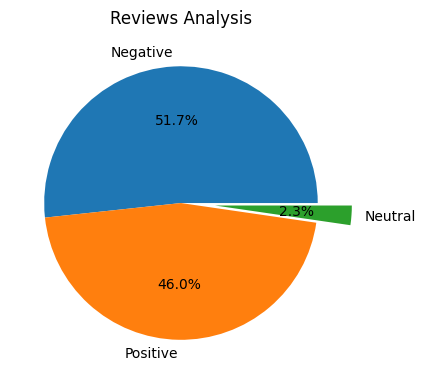

In [18]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Step 1: Get sentiment scores
df['Sentiment Score'] = df['Cleaned Reviews'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

# Step 2: Convert score to labels
def label_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Sentiment Score'].apply(label_sentiment)

# Step 3: Count each category
vader_counts = df['Sentiment'].value_counts()

# Step 4: Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(15,7))

plt.subplot(1,3,2)
plt.title("Reviews Analysis")

plt.pie(
    vader_counts.values,
    labels=vader_counts.index,
    explode=(0, 0, 0.25),
    autopct='%1.1f%%'
)

plt.show()

In [19]:
df.to_csv("BA_reviews.csv")

Visualization using WordCloud

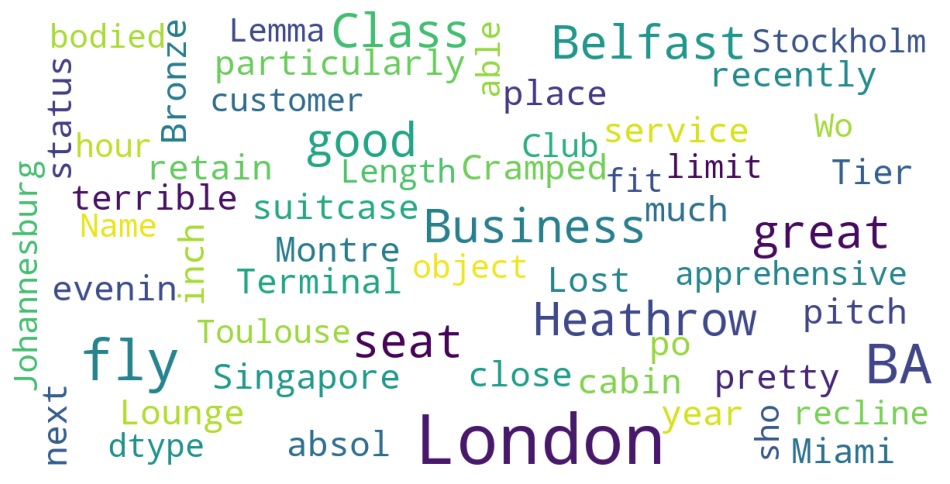

In [20]:
from wordcloud import WordCloud, STOPWORDS
stopwords = set(STOPWORDS)

def show_wordcloud(data):
    wordcloud = WordCloud(
        background_color='white',
        stopwords=stopwords,
        max_words=100,
        max_font_size=30,
        scale=3,
        random_state=1)

    wordcloud=wordcloud.generate(str(data))

    fig = plt.figure(1, figsize=(12, 12))
    plt.axis('off')

    plt.imshow(wordcloud)
    plt.show()

show_wordcloud(df.Lemma)